AARIS-Lite: Academic Analytics & Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
import os
os.listdir("../data")

['Grade_CS_Students.xlsx']

In [3]:
df = pd.read_excel(r"C:\Users\OLUWATOSIN\Desktop\codes/AARIS-LITE/data/Grade_CS_Students.xlsx")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (335, 68)
  Year of enrolment   ID  CS101  CS102  MA101  MA112  MA121  GS101  GS102  \
0         2005-2008  ST1     40     51     40    NaN     40     44     57   
1               NaN  ST2     40     40     46    NaN     40     48     45   
2               NaN  ST3     53     77     45    NaN     40     48     50   
3               NaN  ST4     40     41     40    NaN     40     40     44   
4               NaN  ST5     51     52     50    NaN     40     67     54   

   PH101  ...  CS507  CS508  CS509  CS510  CS512  CS597  CS598  MA419  SW499  \
0     40  ...     50   42.0   67.0   46.0   43.0   63.0   70.0   58.0   63.0   
1     40  ...     41   40.0   49.0   40.0   40.0   60.0   70.0   69.0   70.0   
2     40  ...     54   41.0   67.0   41.0   40.0   62.0   76.0   63.0   66.0   
3     40  ...     44   56.0   55.0   40.0   40.0   66.0   64.0   46.0   66.0   
4     40  ...     52   40.0   40.0   64.0   43.0   60.0   71.0   51.0   66.0   

   MM507  
0    NaN  
1    NaN 

In [4]:
df["Year of enrolment"] = df["Year of enrolment"].ffill()

 DATA RESHAPING (WIDE → LONG FORMAT)

In [5]:
id_vars=["Year of enrolment", "ID"]
long_df = df.melt(
    id_vars=id_vars,
    var_name="Course",
    value_name="Score"
)
print("Reshaped Data:")
print(long_df.head())

Reshaped Data:
  Year of enrolment   ID Course  Score
0         2005-2008  ST1  CS101   40.0
1         2005-2008  ST2  CS101   40.0
2         2005-2008  ST3  CS101   53.0
3         2005-2008  ST4  CS101   40.0
4         2005-2008  ST5  CS101   51.0


In [6]:
long_df = long_df.dropna()

SCORE - GRADE

In [7]:
def assign_grade(score):
    if score >= 70:
        return "A"
    elif score >= 60:
        return "B"
    elif score >= 50:
        return "C"
    elif score >= 45:
        return "D"
    elif score >= 40:
        return "E"
    else:
        return "F"
    
long_df["Grade"] = long_df["Score"].apply(assign_grade)

GRADE-GRADE POINTS

In [8]:
grade_points = {
"A":5,
"B":4,
"C":3,
"D":2,
"E":1,
"F":0

}

long_df["GradePoint"] = long_df["Grade"].map(grade_points)

GPA CALCULATION

In [9]:
gpa_df = long_df.groupby("ID")["GradePoint"].mean().reset_index()
gpa_df.rename(columns={"GradePoint":"GPA"}, inplace=True)
print("GPA Sample")
print(gpa_df.head())

GPA Sample
      ID       GPA
0    ST1  2.377049
1   ST10  2.468750
2  ST100  2.363636
3  ST101  2.621212
4  ST102  2.181818


CGPA CALCULATION

In [10]:
gpa_df["CGPA"] = gpa_df["GPA"].expanding().mean()
print("CGPA Sample")
print(gpa_df.head())

CGPA Sample
      ID       GPA      CGPA
0    ST1  2.377049  2.377049
1   ST10  2.468750  2.422900
2  ST100  2.363636  2.403145
3  ST101  2.621212  2.457662
4  ST102  2.181818  2.402493


EXPLORATORY DATA ANALYSIS

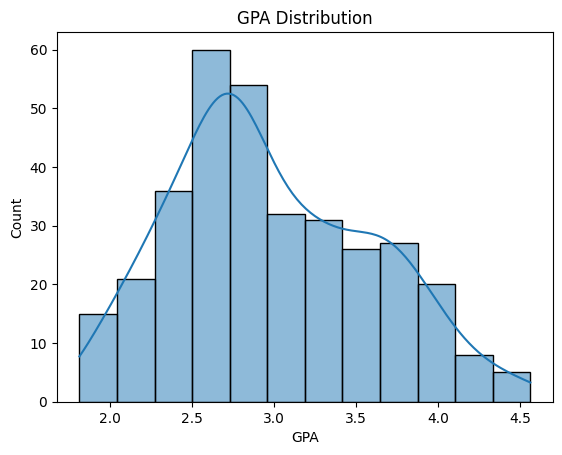

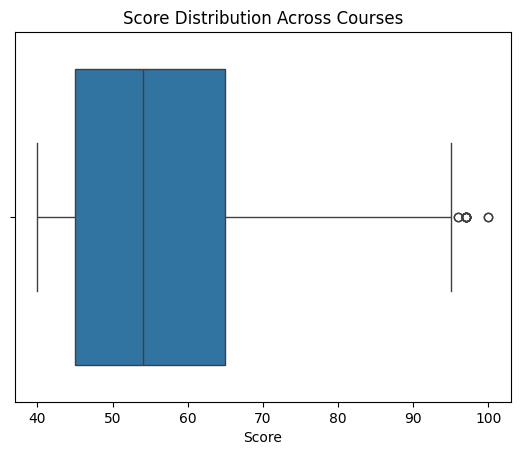

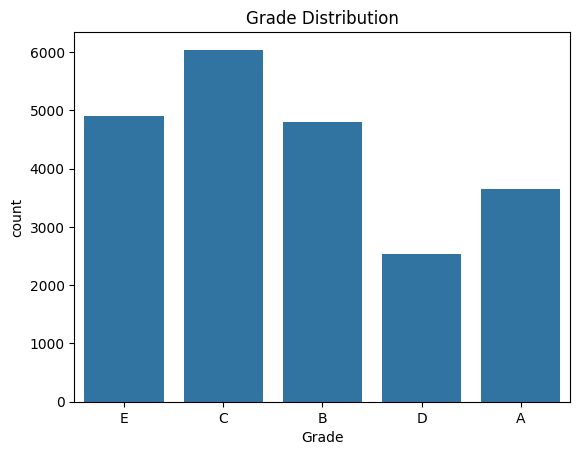

In [11]:
plt.figure()
sns.histplot(gpa_df["GPA"], kde=True)
plt.title("GPA Distribution")
plt.show()
plt.figure()
sns.boxplot(x=long_df["Score"])
plt.title("Score Distribution Across Courses")
plt.show()
plt.figure()
sns.countplot(x=long_df["Grade"])
plt.title("Grade Distribution")
plt.show()

 ANOMALY DETECTION (ISOLATION FOREST)

In [12]:
features_anomaly = long_df[["Score","GradePoint"]]
iso = IsolationForest(contamination=0.05, random_state=42)
long_df["Anomaly"] = iso.fit_predict(features_anomaly)
long_df["Anomaly"] = long_df["Anomaly"].apply(lambda x: 1 if x==-1 else 0)
print("Anomaly Counts")
print(long_df["Anomaly"].value_counts())

Anomaly Counts
Anomaly
0    20974
1      955
Name: count, dtype: int64


Student Performance Statistics

In [13]:
stats_df = long_df.groupby("ID")["Score"].agg(

    Score="mean",
    MaxScore="max",
    MinScore="min",
    ScoreVar="var"

).reset_index()

course_count = long_df.groupby("ID").size().reset_index(name="CourseCount")
stats_df = stats_df.merge(course_count, on="ID")

gpa_df = long_df.groupby("ID")["GradePoint"].mean().reset_index()
gpa_df.rename(columns={"GradePoint":"GPA"}, inplace=True)

gpa_df["CGPA"] = gpa_df.groupby("ID")["GPA"].transform("mean")
model_df = stats_df.merge(gpa_df, on="ID")
print("Model Data Sample:")
print(model_df.head())
print(model_df.shape)

Model Data Sample:
      ID      Score  MaxScore  MinScore    ScoreVar  CourseCount       GPA  \
0    ST1  50.180328      75.0      40.0   99.850273           61  2.377049   
1   ST10  51.578125      79.0      40.0  117.676339           64  2.468750   
2  ST100  50.393939      81.0      40.0   86.765501           66  2.363636   
3  ST101  52.909091      80.0      40.0  103.006993           66  2.621212   
4  ST102  48.954545      77.0      40.0  108.474825           66  2.181818   

       CGPA  
0  2.377049  
1  2.468750  
2  2.363636  
3  2.621212  
4  2.181818  
(335, 8)


In [14]:
X_reg = model_df[[
    "Score",
    "MaxScore",
    "MinScore",
    "ScoreVar",
    "CourseCount"
    ]]
y_reg = model_df["CGPA"]

LINEAR REGRESSION (PREDICT CGPA)

Linear Regression Performance
R2: 0.9897839637784158
RMSE: 0.058671635842108515


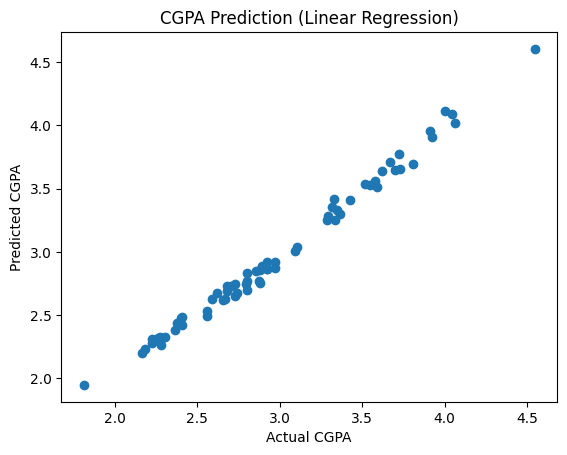

In [15]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42

)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
pred_reg = lr.predict(X_test_reg)
print("Linear Regression Performance")
print("R2:", r2_score(y_test_reg, pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_reg)))
plt.figure()
plt.scatter(y_test_reg, pred_reg)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("CGPA Prediction (Linear Regression)")
plt.show()

In [16]:
train_pred = lr.predict(X_train_reg)

print("Train R2:", r2_score(y_train_reg, train_pred))
print("Test R2:", r2_score(y_test_reg, pred_reg))

Train R2: 0.9914180582033176
Test R2: 0.9897839637784158


In [17]:
print(model_df.head())

      ID      Score  MaxScore  MinScore    ScoreVar  CourseCount       GPA  \
0    ST1  50.180328      75.0      40.0   99.850273           61  2.377049   
1   ST10  51.578125      79.0      40.0  117.676339           64  2.468750   
2  ST100  50.393939      81.0      40.0   86.765501           66  2.363636   
3  ST101  52.909091      80.0      40.0  103.006993           66  2.621212   
4  ST102  48.954545      77.0      40.0  108.474825           66  2.181818   

       CGPA  
0  2.377049  
1  2.468750  
2  2.363636  
3  2.621212  
4  2.181818  


CLASSIFICATION TARGET


In [18]:
model_df["GoodStanding"] = model_df["CGPA"].apply(lambda x: 1 if x>=2.5 else 0)

RANDOM FOREST CLASSIFICATION

In [19]:
X = model_df[["Score", "MaxScore", "MinScore", "ScoreVar","CourseCount"]]
y = model_df["GoodStanding"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42

)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("Confusion Matrix")
print(confusion_matrix(y_test,pred))
print("Classification Report")
print(classification_report(y_test,pred))

Confusion Matrix
[[15  0]
 [ 0 52]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        52

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



FEATURE IMPORTANCE

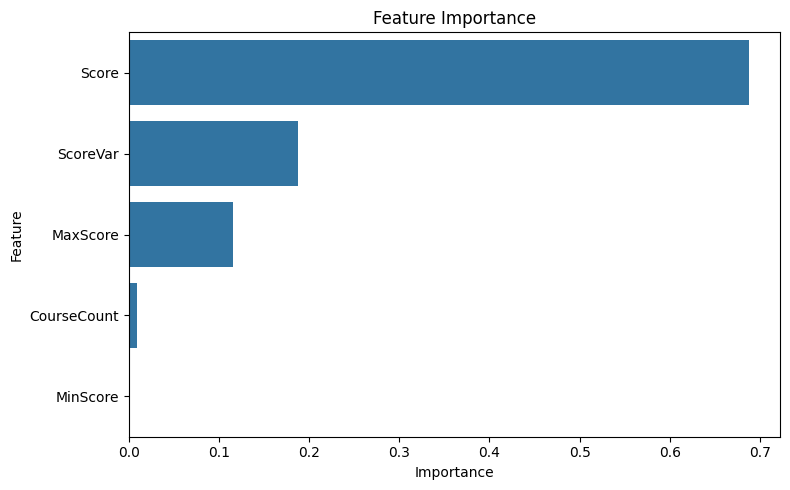

In [20]:
importance_df = pd.DataFrame
import seaborn as sns

importance_df = pd.DataFrame({
    "Feature": X_train_reg.columns,
    "Importance": rf.feature_importances_
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="Importance",y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

SHAP EXPLAINABILITY

c:\Users\OLUWATOSIN\Desktop\codes\codesenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


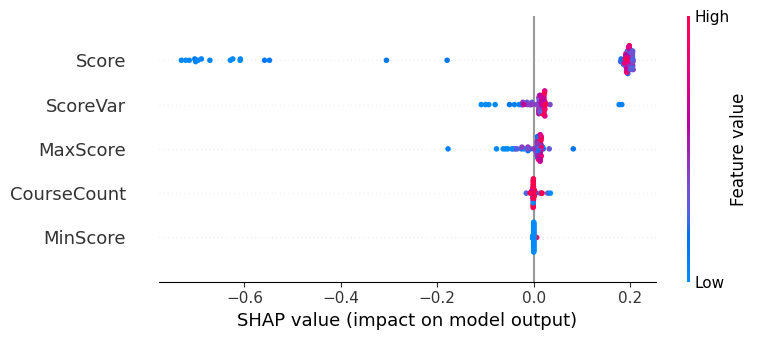

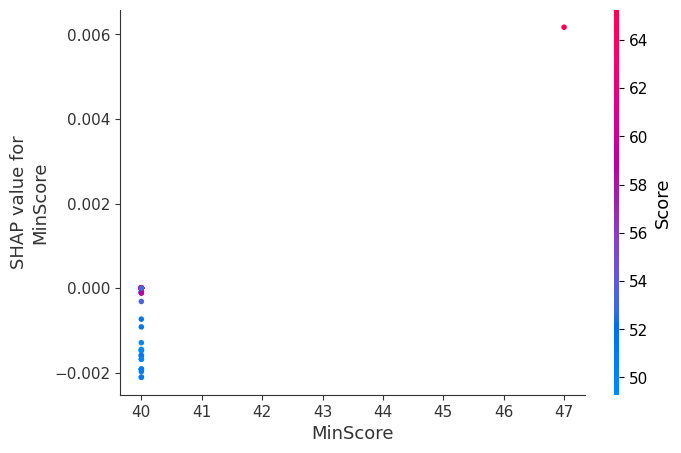

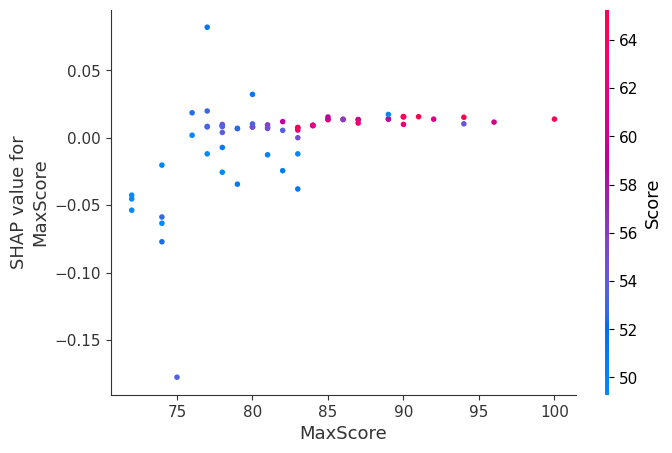

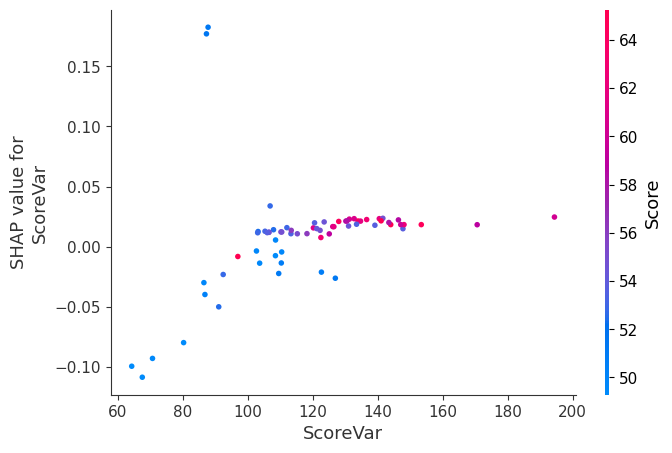

In [21]:
import shap

explainer = shap.TreeExplainer(rf, X_train_reg)
shap_values = explainer.shap_values(X_test_reg)

shap_values = shap_values[:, :, 1]
shap.summary_plot(shap_values, X_test_reg)
shap.dependence_plot("MinScore", shap_values, X_test_reg)
shap.dependence_plot("MaxScore", shap_values, X_test_reg)
shap.dependence_plot("ScoreVar", shap_values, X_test_reg)

RECOMMENDATION ENGINE

In [22]:
def recommendation(gpa):
    if gpa >= 4:
        return "Excellent performance. Maintain strong study habits."
    elif gpa >= 3:
        return "Good performance. Increase revision before exams."
    elif gpa >= 2:
        return "Average performance. Increase study hours."
    else:
        return "Poor performance. Seek academic mentoring."
model_df["Recommendation"] = model_df["GPA"].apply(recommendation)
print(model_df[["ID","GPA","CGPA","Recommendation"]].head())

      ID       GPA      CGPA                              Recommendation
0    ST1  2.377049  2.377049  Average performance. Increase study hours.
1   ST10  2.468750  2.468750  Average performance. Increase study hours.
2  ST100  2.363636  2.363636  Average performance. Increase study hours.
3  ST101  2.621212  2.621212  Average performance. Increase study hours.
4  ST102  2.181818  2.181818  Average performance. Increase study hours.


OUTPUT

In [23]:
model_df.to_csv("AARIS_results.csv", index=False)
print("AARIS analysis completed successfully.")

AARIS analysis completed successfully.


In [24]:
print(model_df["GoodStanding"]. value_counts(normalize=True))

GoodStanding
1    0.785075
0    0.214925
Name: proportion, dtype: float64


In [25]:
import pickle
import os 
os.makedirs("../app", exist_ok=True)
with open("../app/regression_model.pkl", "wb") as f:
    pickle.dump(lr, f)
with open("../app/classifier_model.pkl", "wb") as f:
    pickle.dump(rf, f)
with open("../app/anomaly_model.pkl", "wb") as f:
    pickle.dump(iso, f)
print("Models saved successfully!")

Models saved successfully!
